<a href="https://colab.research.google.com/github/kashif026/brain-tumor-detection-resnet50/blob/main/CNN_Brain_Tumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

model = ResNet50(weights='imagenet')

img_path = '/content/drive/MyDrive/Testing/glioma_tumor/image(1).jpg'
img = keras.utils.load_img(img_path, target_size=(224, 224))
x = keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = model.predict(x)
# decode the results into a list of tuples (class, description, probability)
# (one such list for each sample in the batch)
print('Predicted:', decode_predictions(preds, top=3)[0])
# Predicted: [(u'n02504013', u'Indian_elephant', 0.82658225), (u'n01871265', u'tusker', 0.1122357), (u'n02504458', u'African_elephant', 0.061040461)]


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predicted: [('n03908714', 'pencil_sharpener', np.float32(0.369408)), ('n07930864', 'cup', np.float32(0.07162305)), ('n03724870', 'mask', np.float32(0.0379112))]


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR


In [3]:
# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=5, translate=(0.05,0.05)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [6]:
# ==============================
# Load Dataset
# ==============================

train_dataset = datasets.ImageFolder("/content/drive/MyDrive/Training", transform=train_transform)
val_dataset = datasets.ImageFolder("/content/drive/MyDrive/Testing", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

num_classes = len(train_dataset.classes)

In [8]:
# Load pretrained model
model = models.resnet50(pretrained=True)


In [9]:
# Freeze layers
for param in model.parameters():
    param.requires_grad = False

In [10]:
# Unfreeze last block
for param in model.layer4.parameters():
    param.requires_grad = True

In [11]:
# Replace classifier
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

model = model.to(device)

In [12]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

scheduler = StepLR(optimizer, step_size=7, gamma=0.1)

In [13]:
# Training loop
epochs = 40

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    # Average loss of the epoch
    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/40] Loss: 0.4366
Epoch [2/40] Loss: 0.1974
Epoch [3/40] Loss: 0.1225
Epoch [4/40] Loss: 0.0918
Epoch [5/40] Loss: 0.0934
Epoch [6/40] Loss: 0.0791
Epoch [7/40] Loss: 0.0522
Epoch [8/40] Loss: 0.0390
Epoch [9/40] Loss: 0.0322
Epoch [10/40] Loss: 0.0263
Epoch [11/40] Loss: 0.0192
Epoch [12/40] Loss: 0.0198
Epoch [13/40] Loss: 0.0174
Epoch [14/40] Loss: 0.0172
Epoch [15/40] Loss: 0.0194
Epoch [16/40] Loss: 0.0171
Epoch [17/40] Loss: 0.0186
Epoch [18/40] Loss: 0.0164
Epoch [19/40] Loss: 0.0159
Epoch [20/40] Loss: 0.0164
Epoch [21/40] Loss: 0.0143
Epoch [22/40] Loss: 0.0189
Epoch [23/40] Loss: 0.0165
Epoch [24/40] Loss: 0.0146
Epoch [25/40] Loss: 0.0191
Epoch [26/40] Loss: 0.0187
Epoch [27/40] Loss: 0.0140
Epoch [28/40] Loss: 0.0133
Epoch [29/40] Loss: 0.0146
Epoch [30/40] Loss: 0.0155
Epoch [31/40] Loss: 0.0148
Epoch [32/40] Loss: 0.0148
Epoch [33/40] Loss: 0.0171
Epoch [34/40] Loss: 0.0167
Epoch [35/40] Loss: 0.0177
Epoch [36/40] Loss: 0.0164
Epoch [37/40] Loss: 0.0183
Epoch [38/

In [14]:
    model.eval()

    train_correct = 0
    train_total = 0

    # Calculate training accuracy (optional, but good for reporting)
    with torch.no_grad():
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total

    # ===== PRINT RESULTS =====

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Training Loss: {running_loss/len(train_loader):.4f}")
    print(f"Training Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")
    print("----------------------------------")

Epoch 40/40
Training Loss: 0.0133
Training Accuracy: 99.86%
Validation Accuracy: 77.16%
----------------------------------


In [15]:
torch.save(model.state_dict(), "brain_tumor_model.pth")

Predicted Class: meningioma


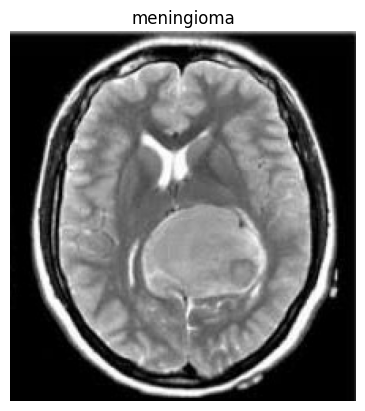

In [20]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# recreate model architecture
model = models.resnet50(pretrained=False)

# change final layer (same as training)
model.fc = nn.Linear(2048, 4)

# load saved weights
model.load_state_dict(torch.load("brain_tumor_model.pth", map_location=device))

model = model.to(device)
model.eval()

# image preprocessing (same as training)
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# class labels
class_names = ["glioma", "meningioma", "notumor", "pituitary"]

# load image
image_path = "/content/drive/MyDrive/Testing/meningioma_tumor/image(109).jpg"

image = Image.open(image_path).convert("RGB")

# preprocess
input_image = transform(image)

# add batch dimension
input_image = input_image.unsqueeze(0).to(device)

# prediction
with torch.no_grad():

    outputs = model(input_image)

    _, predicted = torch.max(outputs, 1)

predicted_class = class_names[predicted.item()]

print("Predicted Class:", predicted_class)

# show image
plt.imshow(image)
plt.title(predicted_class)
plt.axis("off")
plt.show()